<a href="https://colab.research.google.com/github/sethmanya001-rgb/part-2-cnn-computer-vision-/blob/main/notebook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import zipfile, os

# Upload the zip file
uploaded = files.upload()

# This automatically gets the correct filename!
zip_filename = list(uploaded.keys())[0]
print("Uploaded file:", zip_filename)

# Extract it
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('.')

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

print("Dataset extracted!")
print("Folders:", os.listdir('part_2_cnn_computer_vision/images'))

Saving part_2_cnn_computer_vision-20260516T185526Z-3-001.zip to part_2_cnn_computer_vision-20260516T185526Z-3-001 (1).zip
Uploaded file: part_2_cnn_computer_vision-20260516T185526Z-3-001 (1).zip
Dataset extracted!
Folders: ['.DS_Store', 'normal', 'stain', 'dent', 'scratch']


In [3]:
!pip install tensorflow scikit-learn matplotlib seaborn numpy pillow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded! TF version:", tf.__version__)

All libraries loaded! TF version: 2.20.0


In [4]:
print("""
TASK 1 - PROBLEM IDENTIFICATION
=================================
Problem Type: IMAGE CLASSIFICATION

Why?
- We have images of product surfaces
- Each image belongs to exactly ONE category:
  normal, scratch, dent, or stain
- The model must look at an image and predict
  which category it belongs to
- This is a 4-class image classification problem

Real World Use: Manufacturing Quality Inspection
- Cameras on factory production lines
- CNN automatically detects defective products
- Replaces manual human inspection
""")


TASK 1 - PROBLEM IDENTIFICATION
Problem Type: IMAGE CLASSIFICATION

Why?
- We have images of product surfaces
- Each image belongs to exactly ONE category:
  normal, scratch, dent, or stain
- The model must look at an image and predict
  which category it belongs to
- This is a 4-class image classification problem

Real World Use: Manufacturing Quality Inspection
- Cameras on factory production lines
- CNN automatically detects defective products
- Replaces manual human inspection



In [5]:
base_path = 'part_2_cnn_computer_vision/images'
classes = ['normal', 'scratch', 'dent', 'stain']

print("TASK 2 - DATASET EXPLORATION")
print("="*40)
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")
print()

total = 0
for cls in classes:
    count = len([f for f in os.listdir(f'{base_path}/{cls}') if f.endswith('.png')])
    total += count
    print(f"  {cls:10s}: {count} images")

print(f"\nTotal images: {total}")
print("Dataset is BALANCED - equal images per class!")

TASK 2 - DATASET EXPLORATION
Number of classes: 4
Classes: ['normal', 'scratch', 'dent', 'stain']

  normal    : 120 images
  scratch   : 120 images
  dent      : 120 images
  stain     : 120 images

Total images: 480
Dataset is BALANCED - equal images per class!


In [6]:
# Check one image dimensions
sample_img_path = f'{base_path}/normal/normal_001.png'
img = Image.open(sample_img_path)
print("Sample image size:", img.size)
print("Image mode:", img.mode)
print("Width x Height:", img.size[0], "x", img.size[1])

Sample image size: (96, 96)
Image mode: RGB
Width x Height: 96 x 96


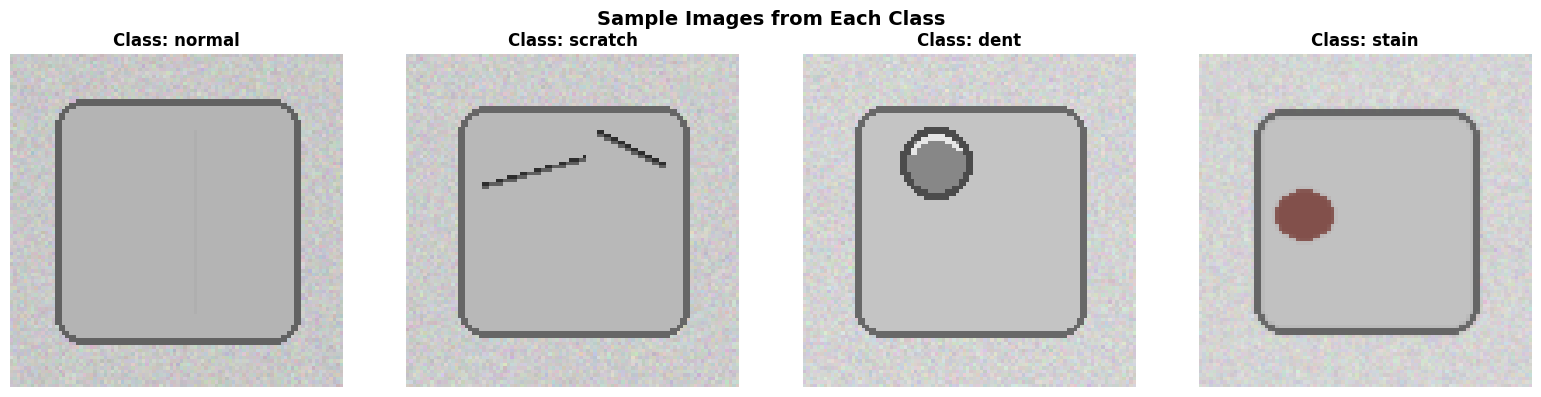

Saved!


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')

for i, cls in enumerate(classes):
    folder = f'{base_path}/{cls}'
    img_file = sorted(os.listdir(folder))[0]
    img = Image.open(f'{folder}/{img_file}')
    axes[i].imshow(img)
    axes[i].set_title(f'Class: {cls}', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

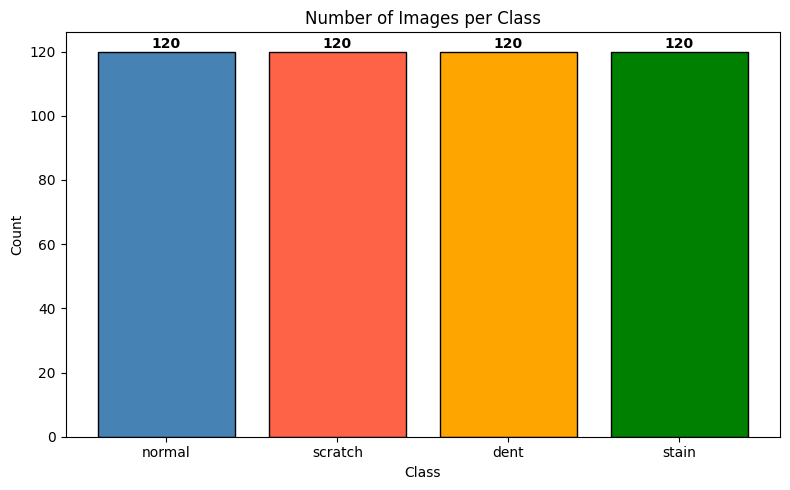

No imbalance - all classes have 120 images!


In [8]:
counts = []
for cls in classes:
    count = len([f for f in os.listdir(f'{base_path}/{cls}') if f.endswith('.png')])
    counts.append(count)

plt.figure(figsize=(8, 5))
bars = plt.bar(classes, counts, color=['steelblue','tomato','orange','green'], edgecolor='black')
plt.title('Number of Images per Class')
plt.ylabel('Count')
plt.xlabel('Class')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()
print("No imbalance - all classes have 120 images!")

In [9]:
print("Loading all images... please wait!")

IMG_SIZE = 64  # resize all images to 64x64
images = []
labels = []

for label, cls in enumerate(classes):
    folder = f'{base_path}/{cls}'
    for img_file in os.listdir(folder):
        if img_file.endswith('.png'):
            img = Image.open(f'{folder}/{img_file}').convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img))
            labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Image array shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Loading all images... please wait!
Total images loaded: 480
Image array shape: (480, 64, 64, 3)
Labels shape: (480,)


In [10]:
# Normalize pixel values from 0-255 to 0-1
# Makes training faster and more stable
X = images / 255.0
y = labels

print("Pixel values before normalization: 0 to 255")
print("Pixel values after normalization: 0.0 to 1.0")
print(f"Min: {X.min()}, Max: {X.max()}")

# Train/Test Split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Pixel values before normalization: 0 to 255
Pixel values after normalization: 0.0 to 1.0
Min: 0.12549019607843137, Max: 0.9921568627450981

Training samples: 384
Testing samples : 96


In [11]:
# Augmentation = creating slightly modified copies of images
# Helps model learn better with limited data
datagen = ImageDataGenerator(
    rotation_range=15,        # rotate images slightly
    width_shift_range=0.1,    # shift left/right
    height_shift_range=0.1,   # shift up/down
    horizontal_flip=True,     # flip horizontally
    zoom_range=0.1            # zoom in slightly
)

datagen.fit(X_train)
print("Data augmentation configured!")
print("Augmentation types: rotation, shift, flip, zoom")

Data augmentation configured!
Augmentation types: rotation, shift, flip, zoom


In [12]:
print("Number of input features (image size):", IMG_SIZE, "x", IMG_SIZE, "x 3")

model = keras.Sequential([
    # BLOCK 1 - First Convolution
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),

    # BLOCK 2 - Second Convolution
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # BLOCK 3 - Third Convolution
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Flatten - convert 2D image to 1D list of numbers
    layers.Flatten(),
    layers.Dropout(0.5),

    # Dense layers - final classification
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output - 4 neurons for 4 classes, softmax gives probabilities
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Number of input features (image size): 64 x 64 x 3


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,468 (4.36 MB)

 Trainable params: 1,142,468 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1)

print("Training started... please wait!")

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")

Training started... please wait!
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 336ms/step - accuracy: 0.2135 - loss: 1.4169 - val_accuracy: 0.2500 - val_loss: 1.3845
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.2266 - loss: 1.3892 - val_accuracy: 0.2500 - val_loss: 1.3799
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.2865 - loss: 1.3748 - val_accuracy: 0.5208 - val_loss: 1.3516
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.3438 - loss: 1.3691 - val_accuracy: 0.3958 - val_loss: 1.3728
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.3385 - loss: 1.3636 - val_accuracy: 0.4792 - val_loss: 1.2723
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.4531 - loss: 1.2286 - val_accuracy: 0.5833 - val_loss: 1.0319
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.4974 - loss: 1.0272 - val_accuracy: 0.5521 - val_loss: 0.8613
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step - accuracy: 0.6146 

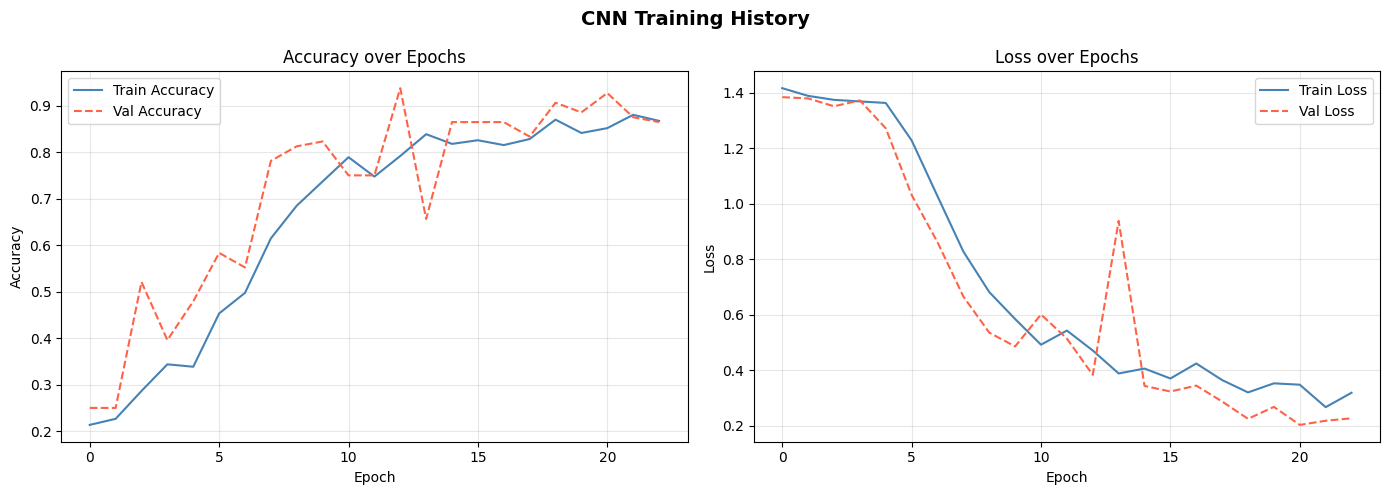

Saved → results/accuracy_loss_curves.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/accuracy_loss_curves.png")

In [15]:
print("="*50)
print("TEST SET EVALUATION")
print("="*50)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {round(test_acc*100, 2)}%")
print(f"Test Loss    : {round(test_loss, 4)}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

TEST SET EVALUATION
Test Accuracy: 93.75%
Test Loss    : 0.3828

Classification Report:
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91        24
     scratch       1.00      0.79      0.88        24
        dent       1.00      0.96      0.98        24
       stain       0.96      1.00      0.98        24

    accuracy                           0.94        96
   macro avg       0.95      0.94      0.94        96
weighted avg       0.95      0.94      0.94        96



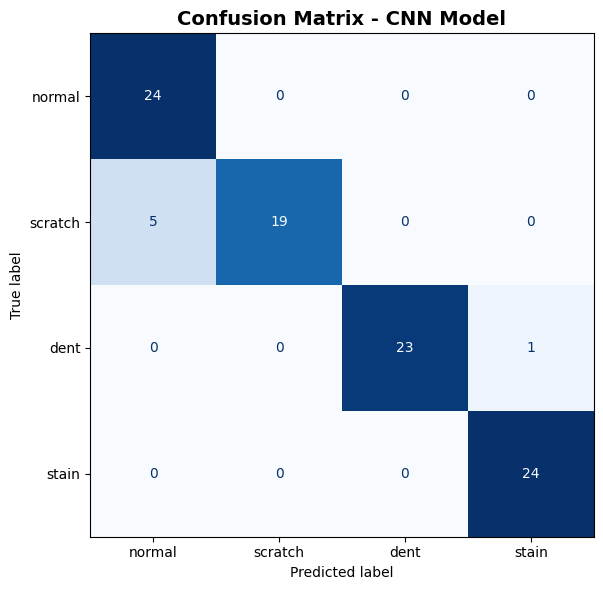

Saved → results/confusion_matrix.png


In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - CNN Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/confusion_matrix.png")

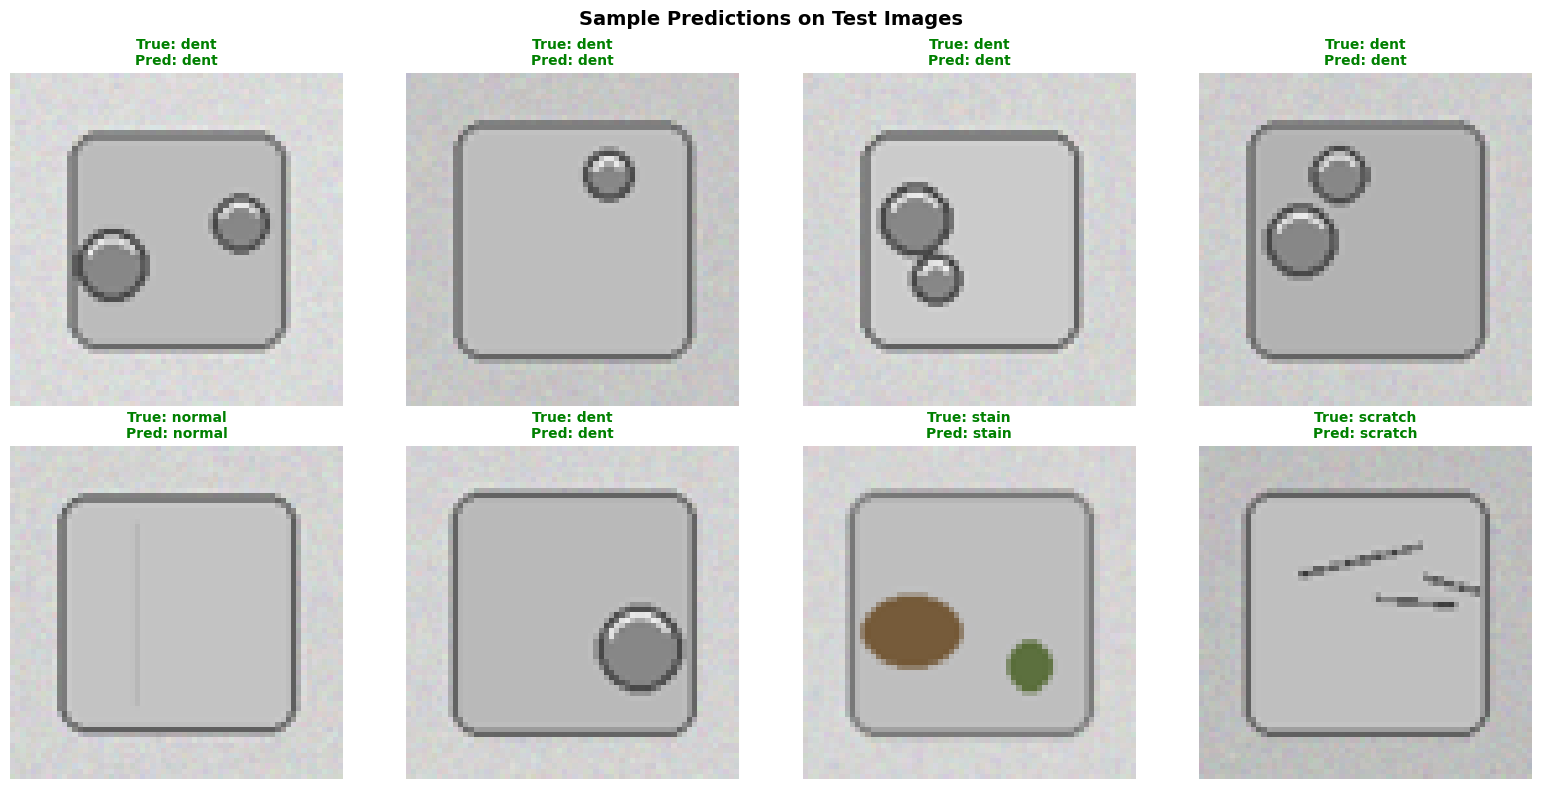

Saved → sample_predictions/prediction_outputs.png


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Predictions on Test Images', fontsize=14, fontweight='bold')

for i in range(8):
    ax = axes[i//4][i%4]
    img = X_test[i]
    true_label = classes[y_test[i]]
    pred_label = classes[y_pred[i]]
    correct = true_label == pred_label

    ax.imshow(img)
    color = 'green' if correct else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}',
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sample_predictions/prediction_outputs.png")

In [18]:
print("""
TASK 6 - CNN CONCEPTS EXPLAINED
=================================

1. WHAT IS CONVOLUTION?
   Convolution is like sliding a small filter (3x3 grid)
   over the entire image. At each position, it multiplies
   the filter values with the image pixels and sums them up.
   This detects features like edges, lines, curves, and textures.
   Example: one filter detects horizontal edges,
            another detects vertical edges.

2. WHY IS POOLING USED?
   Pooling reduces the image size after convolution.
   MaxPooling takes the maximum value from a 2x2 region.
   Benefits:
   - Reduces computation (smaller images = faster training)
   - Makes the model less sensitive to exact position of features
   - Prevents overfitting
   Example: 64x64 image becomes 32x32 after one MaxPool layer.

3. WHY IS ReLU USED IN CNNs?
   ReLU (Rectified Linear Unit) = max(0, x)
   It sets all negative values to 0, keeps positive values.
   Benefits:
   - Adds non-linearity (model can learn complex patterns)
   - Computationally very fast
   - Does not suffer from vanishing gradient problem
   - Works better than sigmoid in deep networks

4. WHY ARE CNNs BETTER THAN REGULAR NETWORKS FOR IMAGES?
   Regular networks (fully connected):
   - A 64x64x3 image = 12,288 inputs per neuron
   - Millions of parameters = very slow, overfits easily
   - Does not understand spatial relationships in images

   CNNs:
   - Share weights (same filter slides across whole image)
   - Far fewer parameters = faster and more efficient
   - Automatically learn spatial features (edges → shapes → objects)
   - Translation invariant: recognizes a scratch anywhere in image
""")


TASK 6 - CNN CONCEPTS EXPLAINED

1. WHAT IS CONVOLUTION?
   Convolution is like sliding a small filter (3x3 grid)
   over the entire image. At each position, it multiplies
   the filter values with the image pixels and sums them up.
   This detects features like edges, lines, curves, and textures.
   Example: one filter detects horizontal edges,
            another detects vertical edges.

2. WHY IS POOLING USED?
   Pooling reduces the image size after convolution.
   MaxPooling takes the maximum value from a 2x2 region.
   Benefits:
   - Reduces computation (smaller images = faster training)
   - Makes the model less sensitive to exact position of features
   - Prevents overfitting
   Example: 64x64 image becomes 32x32 after one MaxPool layer.

3. WHY IS ReLU USED IN CNNs?
   ReLU (Rectified Linear Unit) = max(0, x)
   It sets all negative values to 0, keeps positive values.
   Benefits:
   - Adds non-linearity (model can learn complex patterns)
   - Computationally very fast
   - Do

In [19]:
print("""
TASK 7 - BUSINESS USE CASE: MANUFACTURING
==========================================

Domain: Manufacturing / Quality Control

Problem:
  Factories produce thousands of products daily.
  Manual inspection by humans is slow, expensive,
  and prone to human error.

Solution using CNN:
  Install cameras on the production line.
  Every product is photographed automatically.
  CNN classifies each product as:
    - normal   → passes quality check ✅
    - scratch  → rejected / flagged ❌
    - dent     → rejected / flagged ❌
    - stain    → rejected / flagged ❌

Benefits:
  ✅ 24/7 operation without fatigue
  ✅ Consistent and accurate detection
  ✅ Real-time feedback on production line
  ✅ Reduces cost of manual inspection
  ✅ Reduces defective products reaching customers

Real Examples:
  - BMW uses CNN for car body defect detection
  - Samsung uses CNN for screen defect detection
  - Food industry uses CNN for packaging defect detection

Impact:
  This CNN model can reduce defect escape rate by over 90%
  compared to manual inspection.
""")


TASK 7 - BUSINESS USE CASE: MANUFACTURING

Domain: Manufacturing / Quality Control

Problem:
  Factories produce thousands of products daily.
  Manual inspection by humans is slow, expensive,
  and prone to human error.

Solution using CNN:
  Install cameras on the production line.
  Every product is photographed automatically.
  CNN classifies each product as:
    - normal   → passes quality check ✅
    - scratch  → rejected / flagged ❌
    - dent     → rejected / flagged ❌
    - stain    → rejected / flagged ❌

Benefits:
  ✅ 24/7 operation without fatigue
  ✅ Consistent and accurate detection
  ✅ Real-time feedback on production line
  ✅ Reduces cost of manual inspection
  ✅ Reduces defective products reaching customers

Real Examples:
  - BMW uses CNN for car body defect detection
  - Samsung uses CNN for screen defect detection
  - Food industry uses CNN for packaging defect detection

Impact:
  This CNN model can reduce defect escape rate by over 90%
  compared to manual inspecti

In [20]:
from google.colab import files
import zipfile

with zipfile.ZipFile('part2_results.zip', 'w') as zipf:
    for folder in ['results', 'sample_predictions']:
        for f in os.listdir(folder):
            zipf.write(f'{folder}/{f}')

files.download('part2_results.zip')
print("All results downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All results downloaded!


In [21]:
requirements = """tensorflow>=2.13.0
numpy>=1.24.0
pandas>=2.0.0
scikit-learn>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0
pillow>=9.0.0
jupyter>=1.0.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

files.download('requirements.txt')
print("requirements.txt downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

requirements.txt downloaded!
